In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import silhouette_score
from scipy.stats import mode



In [ ]:
digits = load_digits()
x = digits.data
y = digits.target

In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [ ]:
print("Inertia:", kmeans.inertia_)

Inertia: 65012.19362335784


In [ ]:
sil_score = silhouette_score(x_scaled, cluster_labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.15048580377273424


In [ ]:
k = 12  # digits 0–9

kmeans = KMeans(n_clusters=12, random_state=33, n_init=10)
kmeans.fit(x_scaled)

cluster_labels = kmeans.labels_

In [ ]:
labels = np.zeros_like(cluster_labels)

for i in range(k):
    mask = (cluster_labels == i)
    labels[mask] = mode(y[mask], keepdims=True)[0]

print("Clustering Accuracy:",
      accuracy_score(y, labels))

Clustering Accuracy: 0.7072899276572064


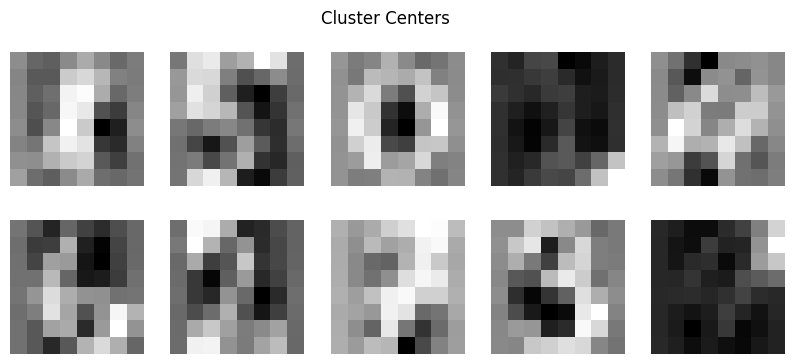

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

centers = kmeans.cluster_centers_

for ax, center in zip(axes.flat, centers):
    ax.imshow(center.reshape(8, 8), cmap='gray')
    ax.axis('off')

plt.suptitle("Cluster Centers")
plt.show()

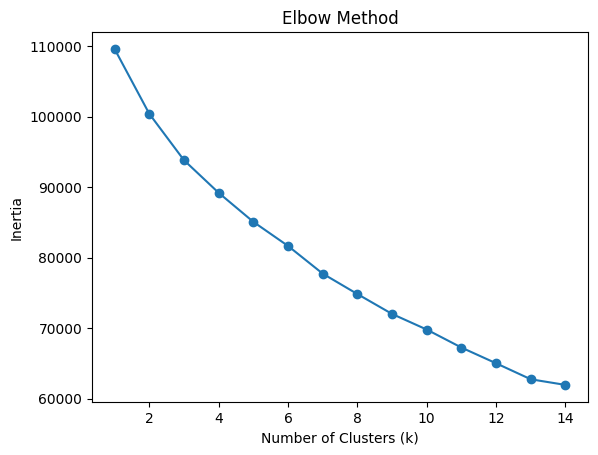

In [ ]:
inertias = []

for k in range(1, 15):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_scaled)
    inertias.append(km.inertia_)

plt.plot(range(1, 15), inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()